# Klasifikasi DemogPairs Menggunakan ViT (Umur) & XGBoost

In [1]:
import numpy as np
import utils as u
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

joblib.parallel_backend('threading')

C:\Users\Rezky\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [3]:
features = joblib.load('features/demogpairs_vit-age.pkl')
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

Jumlah fitur per gambar: 768


## Split Data

In [4]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [5]:
grid_params = [
    {
        'classifier': [XGBClassifier(n_jobs=1, random_state=42)],
        'classifier__tree_method': ['approx', 'hist'],
        'classifier__max_depth': [3, 6, 8],
        'classifier__gamma': [0.0, 0.1, 0.3],
        'classifier__min_child_weight': [1, 3, 5],
    }
]

pipeline = Pipeline(steps=[
    ('classifier', None)
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).split('(')[0]
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.8),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

XGBClassifier: 54 kombinasi


## Klasifikasi

Mengevaluasi model: XGBClassifier
Fitting 5 folds for each of 54 candidates, totalling 270 fits


{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'hist'}


Accuracy  : 0.7893518518518519
Precision : 0.789478982397203
Recall    : 0.789351851851852
F1 Score  : 0.7890046620277698
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       360
           1       0.82      0.75      0.78       360
           2       0.77      0.75      0.76       360
           3       0.80      0.84      0.82       360
           4       0.77      0.76      0.77       360
           5       0.78      0.81      0.79       360

    accuracy                           0.79      2160
   macro avg       0.79      0.79      0.79      2160
weighted avg       0.79      0.79      0.79      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.9365740740740741,0.7973333333333333,0.8305555555555556,0.8136054421768707
White_Females,0.9305555555555556,0.8162650602409639,0.7527777777777778,0.7832369942196532
Asian_Males,0.9203703703703704,0.7685714285714286,0.7472222222222222,0.7577464788732394
White_Males,0.937962962962963,0.800531914893617,0.8361111111111111,0.8179347826086957
Black_Females,0.9231481481481482,0.7740112994350282,0.7611111111111111,0.7675070028011205
Asian_Females,0.9300925925925926,0.7801608579088471,0.8083333333333333,0.7939972714870396


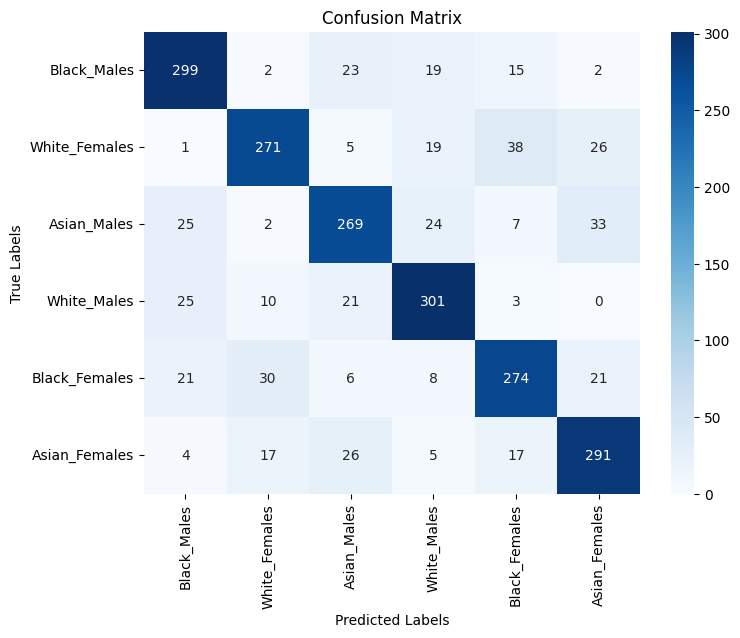

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
XGBClassifier,models/clf_demogpairs_xgb_vit-age_XGBClassifier.pkl,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'hist'}",0.7893518518518519,0.7890046620277698,0.789478982397203,0.789351851851852,54


In [6]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_xgb_vit-age_',
    results_path='results/demogpairs_xgb_vit-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [7]:
model, training_time = u.load_object('models/clf_demogpairs_xgb_vit-age_XGBClassifier.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 21471.0,
 'days': 0,
 'hours': 5,
 'minutes': 57,
 'seconds': 51.0,
 'text': '0 hari 5 jam 57 menit 51.0 detik'}

In [8]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 188496.0,
 'days': 2,
 'hours': 4,
 'minutes': 21,
 'seconds': 36.0,
 'text': '2 hari 4 jam 21 menit 36.0 detik'}

In [9]:
_dtable = u.display_table(fold_results, n_items=[4, 4], column_widths=['5%', '45%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Accuracy Mean,F1 Score Mean,Precision Mean,Recall Mean,Train Time Mean
1,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'hist'}",0.7784,0.7795,0.7743,0.7807,0.7847,0.7795,0.7791,0.7797,0.7795,254.1642
2,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 6, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'hist'}",0.7795,0.7691,0.7784,0.7801,0.7876,0.7789,0.7785,0.7791,0.7789,273.6853
3,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.7859,0.7639,0.7749,0.7951,0.7703,0.778,0.7778,0.7783,0.778,324.5907
4,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.1, 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'hist'}",0.7726,0.7812,0.7749,0.783,0.776,0.7775,0.777,0.7776,0.7775,242.8974
...,...,...,...,...,...,...,...,...,...,...,...
51,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.1, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.7552,0.7436,0.7396,0.7477,0.7396,0.7451,0.7444,0.7457,0.7451,318.2135
52,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'approx'}",0.7483,0.7309,0.7402,0.7436,0.7512,0.7428,0.7422,0.7429,0.7428,1236.1535
53,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.7326,0.7361,0.7292,0.7425,0.7315,0.7344,0.7336,0.7347,0.7344,260.433
54,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}",0.7413,0.7303,0.7147,0.7471,0.7257,0.7318,0.731,0.7316,0.7318,1246.1276
